[INFO] Loaded OPENAI_API_KEY from secret.py


Keyword arguments {'verbose': False} are not expected by InversableStableDiffusionPipeline and will be ignored.
`torch_dtype` is deprecated! Use `dtype` instead!


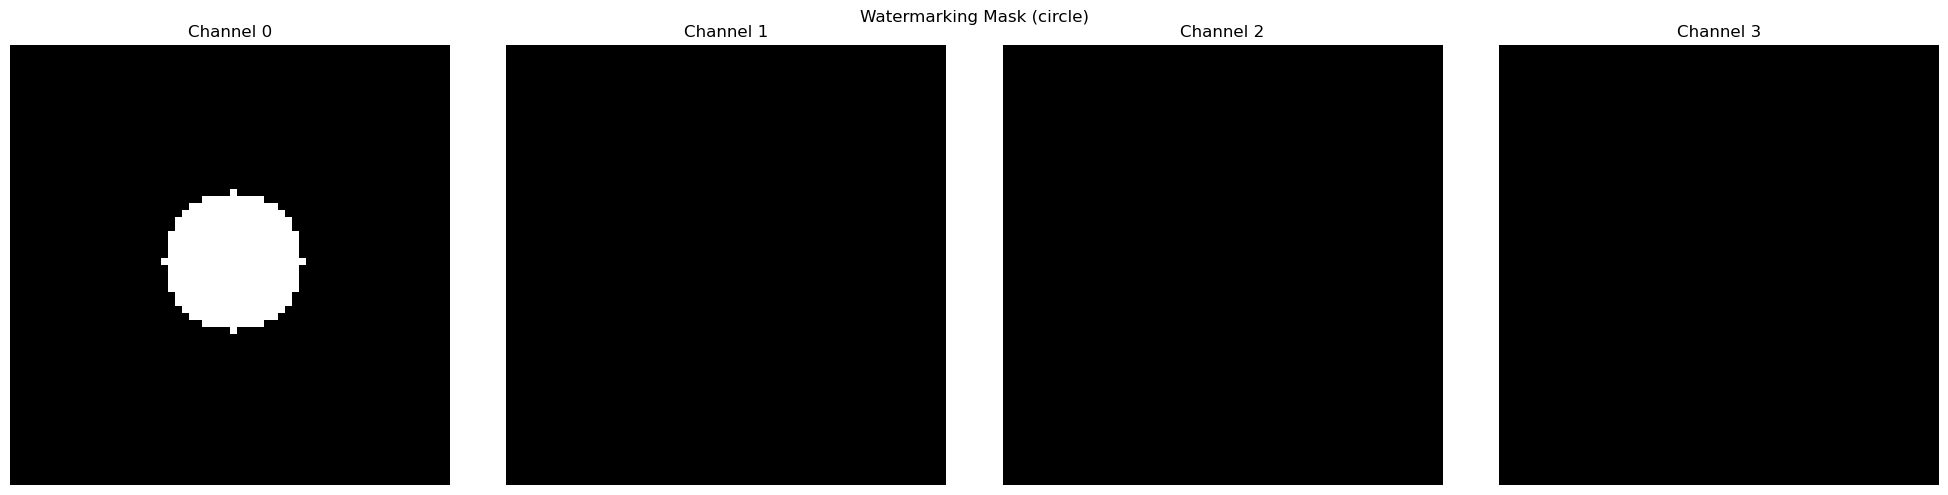

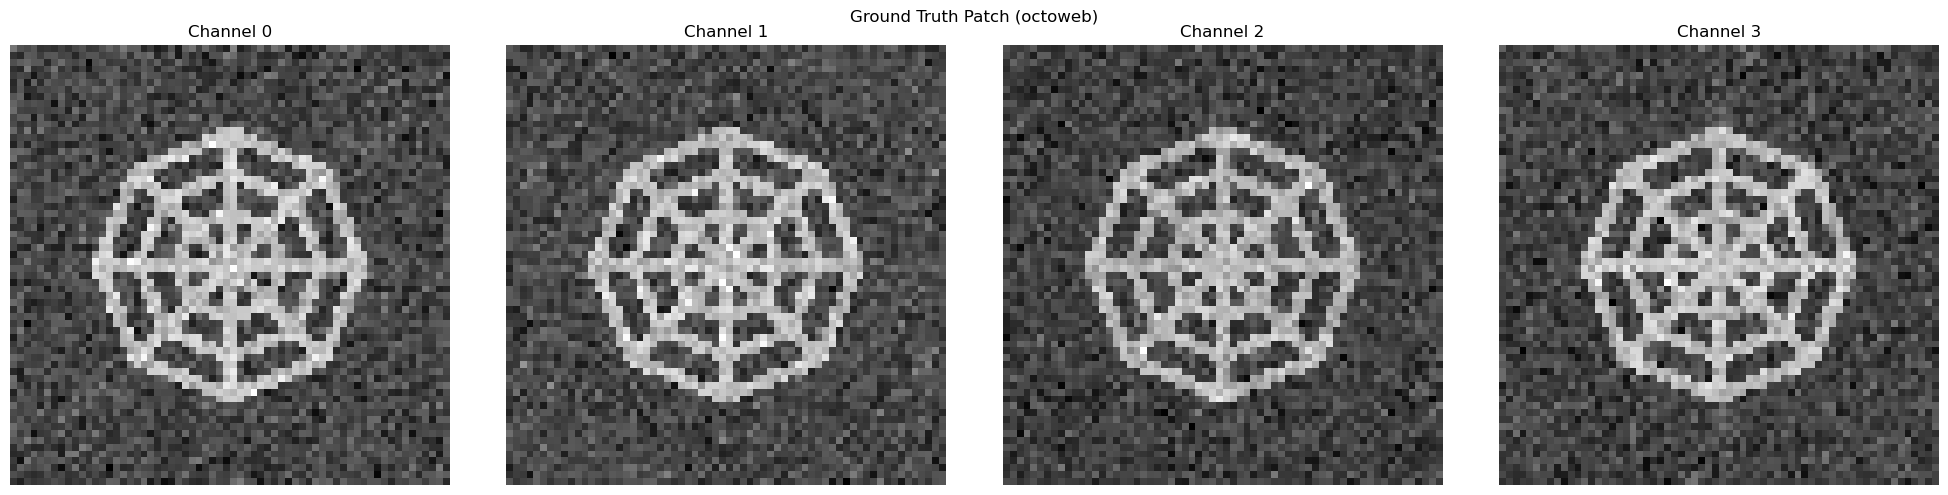

[INFO] inferred in_ch = 8
[INFO] meta attack tasks: ['clean', 'downup50', 'crop', 'jpeg', 'blur', 'msg_app', 'occlusion']
[INFO] meta param count: 64 numel: 11225282
[START] iteration-based meta training
  NUM_ITERS=10 META_BATCH=3 INNER_STEPS=1 FIRST_ORDER=True
[TIMING] logging speed/ETA to ./verifier_dataset_stablediff_octoweb_verifier_meta_iter_10_timing.csv
[SCHEDULER] logging LLM decisions to ./verifier_dataset_stablediff_octoweb_verifier_meta_iter_10_llm_scheduler.jsonl

[STEP 0] Starting meta-training step...
  Doing task 1/3...
[LLMResidualTaskController] OpenAI API HTTP 429: {
  "error": {
    "message": "You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.",
    "type": "insufficient_quota",
    "param": null,
    "code": "insufficient_quota"
  }
}
    Inner step 1/1 for task 'downup50'...
  Doing task 2/3...
    Inner step 1/1 for task 'c

In [1]:
# resume_fft_detector_meta_iter.py
# Iteration-based meta-learning training 
# - Outer loop: for step in range(NUM_ITERS)
# - For each step: sample META_BATCH tasks, do inner(1) then outer, accumulate meta_loss, then optimizer.step()
# - Optimizer: SGD + momentum + nesterov 
# - Logging: every LOG_INTERVAL print what task(s) are running + loss
# - Eval: every EVAL_INTERVAL run validation (aug + no-aug)

import matplotlib.pyplot as plt
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_NOTEBOOK"] = "0"
os.environ["IPYTHON_DISABLE_WIDGETS"] = "1"

# Optional local secret loader. Keep secret.py out of git.
try:
    from secret import OPENAI_API_KEY
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
    print("[INFO] Loaded OPENAI_API_KEY from secret.py")
except Exception as e:
    print(f"[WARN] OPENAI_API_KEY not loaded from secret.py: {e}")

import time
import json
import copy
import random
import warnings
from datetime import datetime, timedelta

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

# ----------------- your imports -----------------
from ds import (
    WatermarkOnTheFlyDataset,
    discover_dataset_files,
    build_meta_attack_tasks,
    WatermarkMetaTaskDataset,
)
from attack import make_train_image_augmentations
from engine import safe_eval_call, safe_eval_call_psnr_l1
from watermark import get_watermarking_mask, get_watermarking_pattern
from utils.vis import visualise_noise

import diffusers
from diffusers import DPMSolverMultistepScheduler
from inverse_stable_diffusion import InversableStableDiffusionPipeline

from meta.meta_model import make_meta_verifier  # MetaModule-style model (has .params(), .copy(), .update_params())

diffusers.utils.logging.disable_progress_bar()

# ============================================================
# Config 
# ============================================================
# device: '0' -> map to cuda:0
CUDA_DEVICE_STR = "0"
DEVICE = f"cuda:{CUDA_DEVICE_STR}" if torch.cuda.is_available() else "cpu"

# seed: 19980802
SEED = 19980802

# bsize: 24  (this is your *validation* batch size; meta task loader is batch_size=1)
VAL_BATCH_SIZE = 24
NUM_WORKERS = 0  # keep 0 due to on-the-fly diffusion

# smoke-test first; raise to 2000 after logs/loss look sane.
NUM_ITERS = 10

# lr/momentum/weight_decay
LR = 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

# eval/log interval
EVAL_INTERVAL = 100
LOG_INTERVAL = 100

# watermark/diffusion config
DATA_DIR = "./verifier_dataset_stablediff_octoweb"
VALIDATION_SPLIT = 0.15
NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 7.5
IMAGE_SIZE = 512

INCLUDE_MASK_PATCH = False
INCLUDE_PSNR_L1 = True

# watermark params
W_MASK_SHAPE = "circle"
W_CHANNEL = 0
W_RADIUS = 10
W_STRENGTH = 0.99
W_PATTERN = "octoweb"

# meta-learning config
META_N_SUPPORT = 8
META_N_QUERY = 8
META_TASKS_PER_EPOCH = 200  # dataset length (used to define how many task items exist)
INNER_LR = 1e-3
INNER_STEPS = 1
FIRST_ORDER = True

# scheduler / task-pool config
META_ATTACK_TASKS = "all"  # "default", "all", or explicit list like ["clean", "jpeg", "crop"]
SCHEDULER_MODE = "llm_residual"  # "cycle", "uniform", "residual", or "llm_residual"
RESIDUAL_BASE_SAMPLING = "uniform"
RESIDUAL_CONFIG = {
    "model": "gpt-5.1",
    "api_key_env": "OPENAI_API_KEY",
    "api_url": "https://api.openai.com/v1/responses",
    "api_format": "responses",
    "residual_scale": 0.15,
    "call_interval": 5,
    "timeout_sec": 20.0,
    "fallback_on_error": True,
    "log_errors": True,
}

# META_BATCH: meta-batch size (how many tasks per outer step)
# Keep candidate task pool broad, but only sample a few tasks per outer step.
META_BATCH_SIZE = 3

CHECKPOINT_PATH = None
CKPT_NAME = f"{DATA_DIR}_verifier_meta_iter_{NUM_ITERS}.pth" # path to save checkpoints (also used for resuming if CHECKPOINT_PATH is None)

# ============================================================
# Reproducibility
# ============================================================
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Load PIPE + TEXT_EMBEDDINGS
# ============================================================
model_id = "Manojb/stable-diffusion-2-1-base"
scheduler = DPMSolverMultistepScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = InversableStableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    verbose=False,
)
pipe.set_progress_bar_config(disable=True)
pipe = pipe.to(DEVICE)

TEXT_EMBEDDINGS = pipe.get_text_embedding("")
PIPE = pipe

# ============================================================
# Watermark mask / patch
# ============================================================
watermarking_mask = get_watermarking_mask(
    PIPE.get_random_latents(),
    w_mask_shape=W_MASK_SHAPE,
    w_channel=W_CHANNEL,
    w_radius=W_RADIUS,
    device=DEVICE,
)
visualise_noise(watermarking_mask[0], title=f"Watermarking Mask ({W_MASK_SHAPE})")

gt_patch = get_watermarking_pattern(
    PIPE,
    w_seed=SEED,
    w_pattern=W_PATTERN,
    w_radius=W_RADIUS,
    device=DEVICE,
    strength=W_STRENGTH,
    shape=None,
)
visualise_noise(gt_patch[0], title=f"Ground Truth Patch ({W_PATTERN})")

# ============================================================
# Prepare base dataset
# ============================================================
file_paths, labels = discover_dataset_files(DATA_DIR)
combined = list(zip(file_paths, labels))
random.shuffle(combined)
file_paths, labels = zip(*combined)

n_val = int(len(file_paths) * VALIDATION_SPLIT)
val_paths = file_paths[:n_val]
val_labels = labels[:n_val]
train_paths = file_paths[n_val:]
train_labels = labels[n_val:]

# base train ds: start clean (image_aug=None) so tasks control aug deterministically in meta dataset
train_ds = WatermarkOnTheFlyDataset(
    train_paths,
    train_labels,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    device=DEVICE,
    image_aug=None,
    image_aug_prob=0.0,
    watermarking_mask=watermarking_mask,
    gt_patch=gt_patch,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    psnr_return_prob=False,
)

# validation datasets (same as your latest stable choices)
IMG_AUG = make_train_image_augmentations(IMAGE_SIZE)
val_ds = WatermarkOnTheFlyDataset(
    val_paths,
    val_labels,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=1,
    device=DEVICE,
    image_aug=IMG_AUG,
    image_aug_prob=0.5,
    watermarking_mask=watermarking_mask,
    gt_patch=gt_patch,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    psnr_return_prob=False,
)
val_ds_no_aug = WatermarkOnTheFlyDataset(
    val_paths,
    val_labels,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=1,
    device=DEVICE,
    image_aug=None,
    image_aug_prob=0.0,
    watermarking_mask=watermarking_mask,
    gt_patch=gt_patch,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    psnr_return_prob=False,
)

val_loader = DataLoader(val_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
val_loader_no_aug = DataLoader(val_ds_no_aug, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# infer input channels (one expensive call)
sample = train_ds[0]
x0 = sample[0] if isinstance(sample, (list, tuple)) else sample["x"]
in_ch = int(x0.shape[0])
print("[INFO] inferred in_ch =", in_ch)

# ============================================================
# Meta tasks + meta dataset/loader
# ============================================================
tasks = build_meta_attack_tasks(IMAGE_SIZE, task_names=META_ATTACK_TASKS)  # deterministic task pool
assert len(tasks) > 0, "build_meta_attack_tasks returned empty list."
META_TASK_NAMES = [task.name for task in tasks]
print("[INFO] meta attack tasks:", META_TASK_NAMES)
if SCHEDULER_MODE == "llm_residual":
    assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY missing; cannot run llm_residual scheduler."

meta_ds = WatermarkMetaTaskDataset(
    ds=train_ds,
    tasks=tasks,
    n_support=META_N_SUPPORT,
    n_query=META_N_QUERY,
    tasks_per_epoch=META_TASKS_PER_EPOCH,
    seed=SEED,
    task_sampling=SCHEDULER_MODE,
    residual_base_sampling=RESIDUAL_BASE_SAMPLING,
    residual_config=RESIDUAL_CONFIG,
)

meta_loader = DataLoader(
    meta_ds,
    batch_size=1,  # one task per item
    shuffle=False,
    num_workers=0,
)
meta_iter = iter(meta_loader)

# ============================================================
# Build model + optimizer (SGD)
# ============================================================
model = make_meta_verifier(in_ch, include_psnr_l1=INCLUDE_PSNR_L1).to(DEVICE)

# IMPORTANT: MetaModule-style params (NOT model.parameters())
meta_params = model.params()
print("[INFO] meta param count:", len(meta_params), "numel:", sum(int(p.numel()) for p in meta_params))

optimizer = torch.optim.SGD(
    meta_params,
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,
)
crit = nn.CrossEntropyLoss()

# ============================================================
# Helpers
# ============================================================
def _unpack_task(task_batch):
    support = task_batch["support"]
    query = task_batch["query"]

    for split in (support, query):
        split["x"] = split["x"].squeeze(0)
        split["y"] = split["y"].squeeze(0)
        if "extra" in split:
            for k, v in list(split["extra"].items()):
                if torch.is_tensor(v):
                    split["extra"][k] = v.squeeze(0)

    tn = task_batch.get("task_name", None)
    task_name = tn[0] if isinstance(tn, (list, tuple)) else tn
    return support, query, task_name

def make_new_model_fn():
    return make_meta_verifier(in_ch, include_psnr_l1=INCLUDE_PSNR_L1)

def meta_train_step(
    base_model,
    task_batch,
    crit,
    device,
    include_psnr_l1: bool,
    inner_lr: float,
    inner_steps: int = 1,
    first_order: bool = True,
):
    """
      new_model = make_new_model(); new_model.copy(base_model, same_var=True)
      inner_step times:
        loss_s.backward(create_graph=True)
        manual update: new_model.update_params(...)
        zero grad
      outer_loss = crit(new_model(query), yq)
      return outer_loss (tensor)
    """
    support, query, task_name = _unpack_task(task_batch)

    xs = support["x"].to(device, non_blocking=True)
    ys = support["y"].to(device, non_blocking=True)
    xq = query["x"].to(device, non_blocking=True)
    yq = query["y"].to(device, non_blocking=True)

    if include_psnr_l1:
        psnr_s = support["extra"]["psnr"].to(device, non_blocking=True)
        l1_s   = support["extra"]["l1"].to(device, non_blocking=True)
        psnr_q = query["extra"]["psnr"].to(device, non_blocking=True)
        l1_q   = query["extra"]["l1"].to(device, non_blocking=True)

    new_model = make_new_model_fn().to(device)
    new_model.copy(base_model, same_var=True)
    new_model.train()

    # ---- inner loop ----
    inner_lbl_loss_val = None
    for _ in range(inner_steps):
        print(f"    Inner step {_+1}/{inner_steps} for task '{task_name}'...")
        if include_psnr_l1:
            logits_s = new_model(xs, psnr_s, l1_s)
        else:
            logits_s = new_model(xs)

        loss_s = crit(logits_s, ys)
        inner_lbl_loss_val = loss_s.detach()

        # loss.backward(create_graph=True, retain_graph=True)
        loss_s.backward(create_graph=not first_order, retain_graph=True)

        # param <- param - lr * grad
        new_model.update_params(lr_inner=inner_lr, first_order=first_order)

        # new_model.zero_grad()
        new_model.zero_grad(set_to_none=True)

    # ---- outer loss ----
    if include_psnr_l1:
        logits_q = new_model(xq, psnr_q, l1_q)
    else:
        logits_q = new_model(xq)

    outer_loss = crit(logits_q, yq)
    return outer_loss, task_name, inner_lbl_loss_val

# ============================================================
# Resume
# ============================================================
best_val_loss = float("inf")
best_step = None
global_step = 0

if CHECKPOINT_PATH is not None:
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    global_step = int(ckpt.get("global_step", 0))
    print(f"[RESUME] global_step={global_step}")

# ============================================================
# Training (iteration-based)
# ============================================================
total_start = time.time()
start_global_step = global_step
step_times = []
running_window = 0.0
running_window_n = 0
META_BATCH = min(int(META_BATCH_SIZE), len(tasks))

def _fmt_time(sec: float):
    return str(timedelta(seconds=int(sec)))

def _speed_eta(global_step: int):
    completed_this_run = max(1, global_step - start_global_step)
    elapsed = time.time() - total_start
    avg_all = elapsed / completed_this_run
    recent = step_times[-20:] if step_times else [avg_all]
    avg_recent = sum(recent) / max(1, len(recent))
    remaining_steps = max(0, NUM_ITERS - global_step)
    eta_sec = avg_recent * remaining_steps
    finish_at = datetime.now() + timedelta(seconds=eta_sec)
    steps_per_hour = 3600.0 / max(avg_recent, 1e-9)
    return avg_all, avg_recent, eta_sec, finish_at, steps_per_hour

def _scheduler_metrics(meta_ds):
    if not hasattr(meta_ds, "residual_snapshot"):
        return {}
    snap = meta_ds.residual_snapshot()
    if not snap:
        return {}
    return {
        "llm_calls": int(snap.get("llm_call_count", 0)),
        "avg_llm_time_sec": float(snap.get("avg_llm_time_sec", 0.0)),
        "last_llm_time_sec": float(snap.get("last_llm_time_sec", 0.0)),
        "last_llm_error": snap.get("last_llm_error"),
        "last_llm_response": snap.get("last_llm_response"),
        "cached_llm_delta": snap.get("cached_llm_delta"),
    }

def _json_safe(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    return obj

def _scheduler_status(meta_ds):
    metrics = _scheduler_metrics(meta_ds)
    if not metrics:
        return "scheduler=base"
    llm_calls = metrics.get("llm_calls", 0)
    avg_llm = metrics.get("avg_llm_time_sec", 0.0)
    last_llm = metrics.get("last_llm_time_sec", 0.0)
    last_err = metrics.get("last_llm_error")
    msg = f"llm_calls={llm_calls} avg_llm={avg_llm:.1f}s last_llm={last_llm:.1f}s"
    if last_err:
        msg += f" last_llm_error={str(last_err)[:120]}"
    return msg

print("=" * 80)
print("[START] iteration-based meta training")
print(f"  NUM_ITERS={NUM_ITERS} META_BATCH={META_BATCH} INNER_STEPS={INNER_STEPS} FIRST_ORDER={FIRST_ORDER}")
print("=" * 80)

all_meta_losses = []
TIMING_LOG_PATH = CKPT_NAME.replace(".pth", "_timing.csv")
LLM_SCHEDULER_LOG_PATH = CKPT_NAME.replace(".pth", "_llm_scheduler.jsonl")
last_logged_llm_calls = 0
if start_global_step == 0:
    with open(TIMING_LOG_PATH, "w", encoding="utf-8") as f:
        f.write("global_step,step_time_sec,avg_all_sec,avg_recent20_sec,steps_per_hour,eta_sec,finish_at,meta_loss,llm_calls,avg_llm_time_sec,last_llm_time_sec,last_llm_error\n")
    with open(LLM_SCHEDULER_LOG_PATH, "w", encoding="utf-8") as f:
        pass
print(f"[TIMING] logging speed/ETA to {TIMING_LOG_PATH}")
print(f"[SCHEDULER] logging LLM decisions to {LLM_SCHEDULER_LOG_PATH}")

for step in range(global_step, NUM_ITERS):
    print(f"\n[STEP {step}] Starting meta-training step...")
    t_step0 = time.time()
    model.train()

    optimizer.zero_grad(set_to_none=True)

    meta_loss = 0.0
    task_names = []
    inner_losses = []

    for _k in range(META_BATCH):
        print(f"  Doing task {_k+1}/{META_BATCH}...")
        try:
            task_batch = next(meta_iter)
        except StopIteration:
            meta_iter = iter(meta_loader)
            task_batch = next(meta_iter)
        outer_loss, task_name, inner_lbl_loss = meta_train_step(
            base_model=model,
            task_batch=task_batch,
            crit=crit,
            device=DEVICE,
            include_psnr_l1=INCLUDE_PSNR_L1,
            inner_lr=INNER_LR,
            inner_steps=INNER_STEPS,
            first_order=FIRST_ORDER,
        )
        meta_ds.update_task_feedback_from_batch(
            task_batch,
            loss=float(outer_loss.detach().cpu().item()),
        )
        meta_loss = meta_loss + outer_loss
        task_names.append(str(task_name))
        if inner_lbl_loss is not None:
            inner_losses.append(float(inner_lbl_loss.detach().cpu().item()))

    meta_loss = meta_loss / float(META_BATCH)
    meta_loss.backward(create_graph=False, retain_graph=False)
    optimizer.step()

    loss_val = float(meta_loss.detach().cpu().item())
    running_window += loss_val
    running_window_n += 1
    global_step = step + 1
    
    all_meta_losses.append(loss_val)
    dt_step = time.time() - t_step0
    step_times.append(dt_step)
    # plot and save all meta losses to a figure


    # -------- logging --------
    if(step % LOG_INTERVAL) == 0:
        lr_now = optimizer.param_groups[0]["lr"]
        avg_recent = running_window / max(1, running_window_n)
        avg_all_t, avg_recent_t, eta_sec, finish_at, steps_per_hour = _speed_eta(global_step)
        sched_metrics = _scheduler_metrics(meta_ds)
        inner_str = f"{(sum(inner_losses)/len(inner_losses)):.4f}" if inner_losses else "NA"
        print(
            f"[step {step:5d}/{NUM_ITERS}] "
            f"lr={lr_now:.6f} "
            f"meta_loss={loss_val:.4f} "
            f"avg({running_window_n})={avg_recent:.4f} "
            f"inner_loss={inner_str} "
            f"tasks={task_names} "
            f"dt={dt_step:.1f}s "
            f"avg_all={avg_all_t:.1f}s avg_recent20={avg_recent_t:.1f}s "
            f"speed={steps_per_hour:.1f} steps/hr "
            f"eta={_fmt_time(eta_sec)} finish_at={finish_at:%Y-%m-%d %H:%M:%S} "
            f"elapsed={_fmt_time(time.time()-total_start)} "
            f"{_scheduler_status(meta_ds)}"
        )
        running_window = 0.0
        running_window_n = 0

        plt.figure(figsize=(10, 5))
        plt.plot(all_meta_losses, label="Meta Loss")
        plt.xlabel("Meta Training Step")
        plt.ylabel("Meta Loss")
        plt.title("Meta Loss over Time")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.savefig(f"{CKPT_NAME}_meta_loss_plot.png")
        plt.close()
        print(f"Saved meta loss plot to {CKPT_NAME}_meta_loss_plot.png") 

        ckpt = {
            "global_step": global_step,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "meta": {
                "inner_lr": INNER_LR,
                "inner_steps": INNER_STEPS,
                "meta_batch": META_BATCH,
                "meta_batch_size_config": META_BATCH_SIZE,
                "n_support": META_N_SUPPORT,
                "n_query": META_N_QUERY,
            },
            "config": {
                "num_iters": NUM_ITERS,
                "lr": LR,
                "momentum": MOMENTUM,
                "weight_decay": WEIGHT_DECAY,
                "log_interval": LOG_INTERVAL,
                "eval_interval": EVAL_INTERVAL,
                "seed": SEED,
            },
            "scheduler": {
                "mode": SCHEDULER_MODE,
                "meta_attack_tasks": META_ATTACK_TASKS,
                "task_names": META_TASK_NAMES,
                "residual_base_sampling": RESIDUAL_BASE_SAMPLING,
                "residual_config": RESIDUAL_CONFIG,
                "llm_scheduler_log_path": LLM_SCHEDULER_LOG_PATH,
            },
            "timing": {
                "step_times_sec": step_times,
                "timing_log_path": TIMING_LOG_PATH,
                "last_eta_sec": eta_sec,
                "last_finish_at": f"{finish_at:%Y-%m-%d %H:%M:%S}",
                "scheduler_metrics": sched_metrics,
            },
        }
        # save the check point for this step (overwrite)
        torch.save(ckpt, CKPT_NAME)
        print(f"Saved checkpoint to {CKPT_NAME}")
        
    avg_all_t, avg_recent_t, eta_sec, finish_at, steps_per_hour = _speed_eta(global_step)
    sched_metrics = _scheduler_metrics(meta_ds)
    if sched_metrics.get("llm_calls", 0) > last_logged_llm_calls:
        llm_record = {
            "global_step": global_step,
            "candidate_task_names": META_TASK_NAMES,
            "sampled_task_names": task_names,
            "scheduler_mode": SCHEDULER_MODE,
            "residual_base_sampling": RESIDUAL_BASE_SAMPLING,
            "llm_calls": sched_metrics.get("llm_calls", 0),
            "avg_llm_time_sec": sched_metrics.get("avg_llm_time_sec", 0.0),
            "last_llm_time_sec": sched_metrics.get("last_llm_time_sec", 0.0),
            "last_llm_error": sched_metrics.get("last_llm_error"),
            "last_llm_response": sched_metrics.get("last_llm_response"),
            "cached_llm_delta": sched_metrics.get("cached_llm_delta"),
        }
        with open(LLM_SCHEDULER_LOG_PATH, "a", encoding="utf-8") as f:
            f.write(json.dumps(_json_safe(llm_record), ensure_ascii=True) + "\n")
        last_logged_llm_calls = sched_metrics.get("llm_calls", 0)
    last_llm_error = str(sched_metrics.get("last_llm_error") or "").replace("\n", " ").replace(",", ";")
    with open(TIMING_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(
            f"{global_step},{dt_step:.4f},{avg_all_t:.4f},{avg_recent_t:.4f},"
            f"{steps_per_hour:.4f},{eta_sec:.4f},{finish_at:%Y-%m-%d %H:%M:%S},"
            f"{loss_val:.6f},{sched_metrics.get('llm_calls', 0)},"
            f"{sched_metrics.get('avg_llm_time_sec', 0.0):.4f},"
            f"{sched_metrics.get('last_llm_time_sec', 0.0):.4f},"
            f"{last_llm_error}\n"
        )
    print(
        f"Step time: {dt_step:.1f}s | avg_all={avg_all_t:.1f}s | "
        f"avg_recent20={avg_recent_t:.1f}s | speed={steps_per_hour:.1f} steps/hr | "
        f"ETA={_fmt_time(eta_sec)} | finish_at={finish_at:%Y-%m-%d %H:%M:%S}"
    )


ckpt = {
    "global_step": global_step,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "meta": {
        "inner_lr": INNER_LR,
        "inner_steps": INNER_STEPS,
        "meta_batch": META_BATCH,
        "meta_batch_size_config": META_BATCH_SIZE,
        "n_support": META_N_SUPPORT,
        "n_query": META_N_QUERY,
    },
    "config": {
        "num_iters": NUM_ITERS,
        "lr": LR,
        "momentum": MOMENTUM,
        "weight_decay": WEIGHT_DECAY,
        "log_interval": LOG_INTERVAL,
        "eval_interval": EVAL_INTERVAL,
        "seed": SEED,
    },
    "scheduler": {
        "mode": SCHEDULER_MODE,
        "meta_attack_tasks": META_ATTACK_TASKS,
        "task_names": META_TASK_NAMES,
        "residual_base_sampling": RESIDUAL_BASE_SAMPLING,
        "residual_config": RESIDUAL_CONFIG,
        "llm_scheduler_log_path": LLM_SCHEDULER_LOG_PATH,
    },
    "timing": {
        "step_times_sec": step_times,
        "timing_log_path": TIMING_LOG_PATH,
        "scheduler_metrics": _scheduler_metrics(meta_ds),
    },
}
torch.save(ckpt, f"{CKPT_NAME}".replace(".pth", "_final.pth"))
print("=" * 80)
print("[DONE] Training complete.")
print(f"Best val_noaug_loss: {best_val_loss:.6f} @ step {best_step}")
print(f"Last global_step: {global_step}")

In [ ]:
f"last_{CKPT_NAME}"

'last_./verifier_dataset_stablediff_octoweb_verifier_meta_iter_100.pth'